<h1>Initialization</h1>

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import joblib

<h1>Data Collection</h1>

In [24]:
df = pd.read_csv(filepath_or_buffer="../data/housing.csv")

<h1>EDA</h1>

In [25]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [26]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [27]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [28]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [29]:
df.ocean_proximity.unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

<h1>Splitting</h1>

In [30]:
numeric_cols = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income']
categorical_cols = ['ocean_proximity']

SLR_X = df[["median_income"]]
SLR_Y = df["median_house_value"]

MLR_X = df.drop(axis=1, columns="median_house_value")
MLR_Y = df["median_house_value"]

In [31]:
X_train_SLR, X_test_SLR, Y_train_SLR, Y_test_SLR = train_test_split(SLR_X, SLR_Y, random_state=42, test_size=0.2)

X_train_MLR, X_test_MLR, Y_train_MLR, Y_test_MLR = train_test_split(MLR_X, MLR_Y, random_state=42, test_size=0.2)

<h1>Analyse</h1>

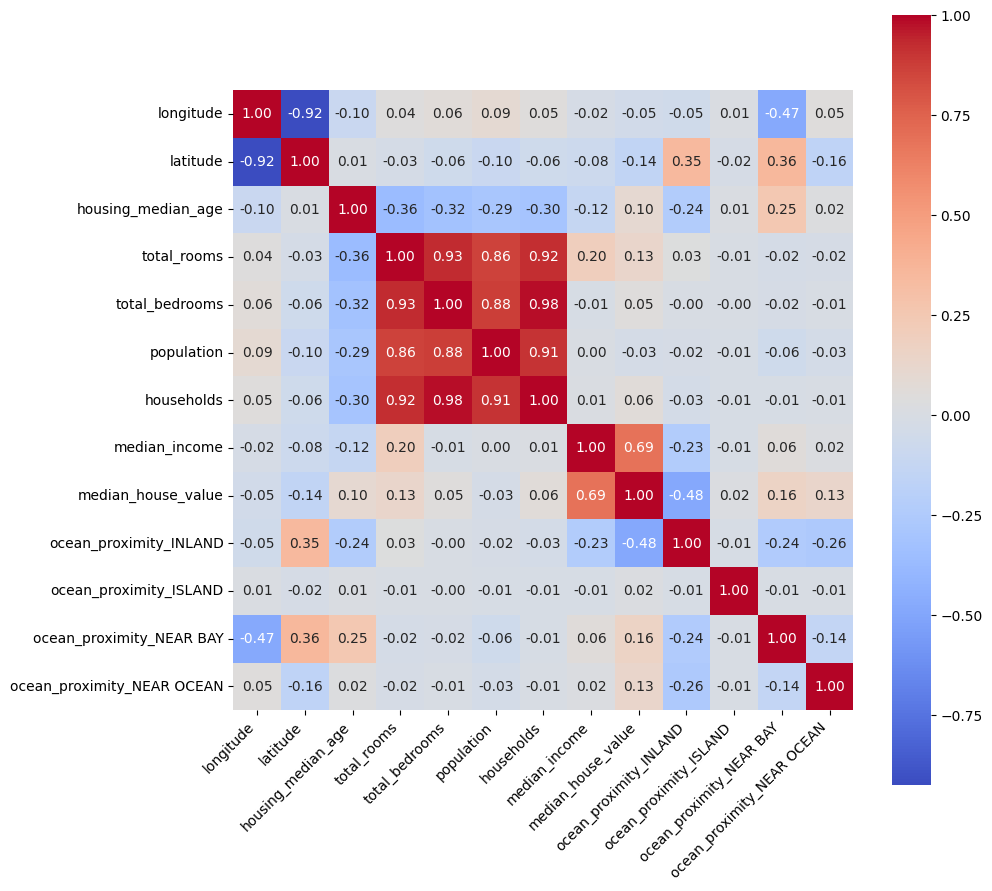

In [32]:
tmp_df = X_train_MLR.copy()
tmp_df["median_house_value"] = Y_train_MLR.values
encodded_df = pd.get_dummies(data=tmp_df, columns=["ocean_proximity"], drop_first=True)
encodded_df = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(encodded_df),
    columns=encodded_df.columns
)

correlated_df = encodded_df.corr()

plt.figure(figsize=(10,10))
sns.heatmap(correlated_df, square=True,
            annot=True, annot_kws={"size": 10},
            fmt="0.2f", cmap="coolwarm")
plt.xticks(rotation=45, ha="right")
plt.show()

<h1>Pipelines</h1>

In [33]:
# SLR Pipeline
SLR_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

# MLR Pipeline
numerical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("numerical", numerical_preprocessor, numeric_cols),
    ("categorical", OneHotEncoder(drop="first", sparse_output=False), categorical_cols)
])

MLR_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

<h1>Cross Validation</h1>

In [34]:
SLR_cv_scores = cross_val_score(
    SLR_pipeline, X_train_SLR, Y_train_SLR,
    cv=5, scoring='r2'
)

print('--- SLR Cross Validation (R2) ---')
print(f'Scores:  {SLR_cv_scores.round(4)}')
print(f'Mean:    {SLR_cv_scores.mean():.4f}')
print(f'Std:     {SLR_cv_scores.std():.4f}')


MLR_cv_scores = cross_val_score(
    MLR_pipeline, X_train_MLR, Y_train_MLR,
    cv=5, scoring='r2'
)

print('\n--- MLR Cross Validation (R2) ---')
print(f'Scores:  {MLR_cv_scores.round(4)}')
print(f'Mean:    {MLR_cv_scores.mean():.4f}')
print(f'Std:     {MLR_cv_scores.std():.4f}')

--- SLR Cross Validation (R2) ---
Scores:  [0.4834 0.4795 0.4731 0.469  0.4786]
Mean:    0.4767
Std:     0.0051

--- MLR Cross Validation (R2) ---
Scores:  [0.6551 0.6491 0.66   0.6469 0.6266]
Mean:    0.6476
Std:     0.0114


<h1>GridSearch</h1>

In [35]:
# SLR GridSearch
SLR_grid_param = {
    "imputer__strategy": ["mean", "median"],
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

SLR_grid = GridSearchCV(
    SLR_pipeline, SLR_grid_param,
    cv=5, scoring="r2", n_jobs=-1
)
SLR_grid.fit(X_train_SLR, Y_train_SLR)

print('--- SLR GridSearch ---')
print(f"Best params: {SLR_grid.best_params_}")
print(f"Best R2: {SLR_grid.best_score_:.4f}")

# MLR GridSearch
MLR_grid_param = {
    "preprocessor__numerical__imputer__strategy": ["mean", "median"],
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

MLR_grid = GridSearchCV(
    MLR_pipeline, MLR_grid_param,
    cv=5, scoring="r2", n_jobs=-1
)
MLR_grid.fit(X_train_MLR, Y_train_MLR)

print('\n--- MLR GridSearch ---')
print(f'Best params: {MLR_grid.best_params_}')
print(f'Best R2:     {MLR_grid.best_score_:.4f}')

--- SLR GridSearch ---
Best params: {'imputer__strategy': 'mean', 'model__alpha': 1}
Best R2: 0.4767

--- MLR GridSearch ---
Best params: {'model__alpha': 1, 'preprocessor__numerical__imputer__strategy': 'mean'}
Best R2:     0.6476


<h1>Final Evaluation</h1>

In [36]:
SLR_test_predictions = SLR_grid.best_estimator_.predict(X_test_SLR)
MLR_test_predictions = MLR_grid.best_estimator_.predict(X_test_MLR)

print('--- SLR Test ---')
print(f'R^2=  {metrics.r2_score(Y_test_SLR, SLR_test_predictions):.4f}')
print(f'MSE=  {metrics.mean_squared_error(Y_test_SLR, SLR_test_predictions):.4f}')
print(f'RMSE= {metrics.root_mean_squared_error(Y_test_SLR, SLR_test_predictions):.4f}')

print('\n--- MLR Test ---')
print(f'R^2=  {metrics.r2_score(Y_test_MLR, MLR_test_predictions):.4f}')
print(f'MSE=  {metrics.mean_squared_error(Y_test_MLR, MLR_test_predictions):.4f}')
print(f'RMSE= {metrics.root_mean_squared_error(Y_test_MLR, MLR_test_predictions):.4f}')

--- SLR Test ---
R^2=  0.4589
MSE=  7091144941.7682
RMSE= 84208.9362

--- MLR Test ---
R^2=  0.6256
MSE=  4905583485.9735
RMSE= 70039.8707


<h1>Retraining on full data</h1>

In [37]:
SLR_final = SLR_grid.best_estimator_
MLR_final = MLR_grid.best_estimator_

SLR_final.fit(SLR_X, SLR_Y)
MLR_final.fit(MLR_X, MLR_Y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('categorical',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['ocean_proximity'])])),
                ('model', Ridge(alpha=1))])

<h1>Export</h1>

In [38]:
joblib.dump(SLR_final, "../models/SLR_Model.pkl")
joblib.dump(MLR_final, "../models/MLR_Model.pkl")

['../models/MLR_Model.pkl']

<h1>Load trained model</h1>

In [39]:
SLR_loaded = joblib.load('../models/SLR_Model.pkl')
MLR_loaded = joblib.load('../models/MLR_Model.pkl')

print('SLR sample prediction:', SLR_loaded.predict(X_test_SLR.iloc[:3]))
print('MLR sample prediction:', MLR_loaded.predict(X_test_MLR.iloc[:3]))

SLR sample prediction: [115353.82921733 150881.05914335 190533.14213805]
MLR sample prediction: [ 61077.40247228 138043.05315233 280869.6640417 ]


<h1>Comparasion</h1>

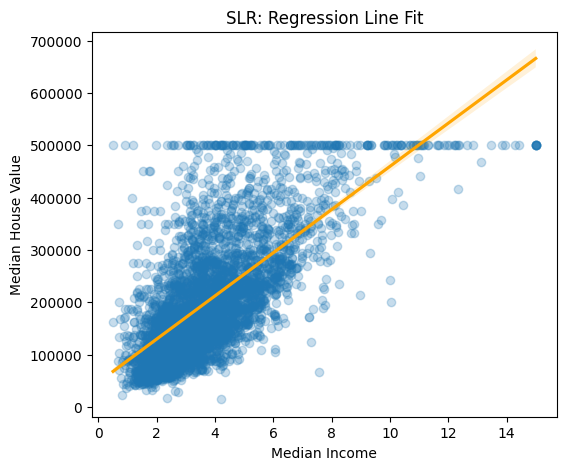

In [40]:
plt.figure(figsize=(6, 5))
sns.regplot(
    x=X_test_SLR['median_income'],
    y=Y_test_SLR,
    scatter_kws={'alpha': 0.25},
    line_kws={'color': 'orange'}
)
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('SLR: Regression Line Fit')
plt.show()

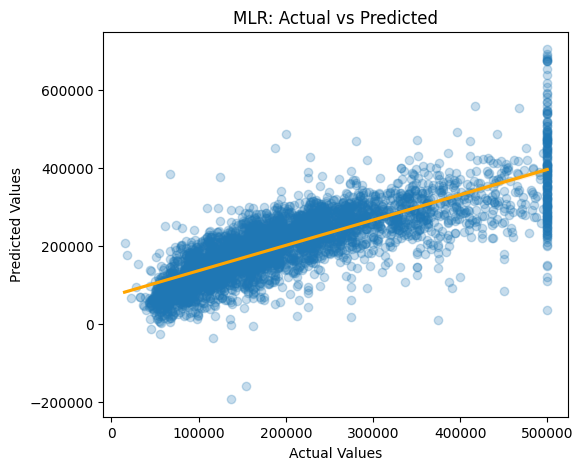

In [41]:
plt.figure(figsize=(6, 5))
sns.regplot(
    x=Y_test_MLR,
    y=MLR_test_predictions,
    scatter_kws={'alpha': 0.25},
    line_kws={'color': 'orange'}
)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('MLR: Actual vs Predicted')
plt.show()

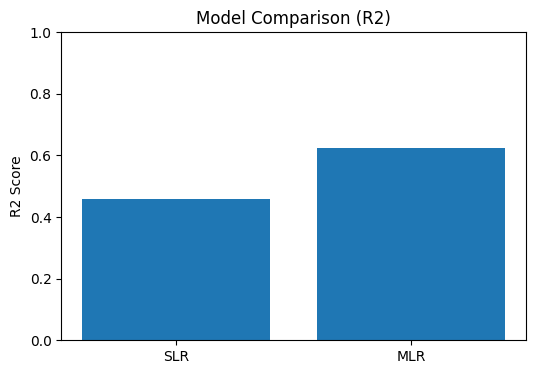

In [42]:
plt.figure(figsize=(6, 4))
plt.bar(
    ['SLR', 'MLR'],
    [metrics.r2_score(Y_test_SLR, SLR_test_predictions),
     metrics.r2_score(Y_test_MLR, MLR_test_predictions)]
)
plt.ylabel('R2 Score')
plt.title('Model Comparison (R2)')
plt.ylim(0, 1)
plt.show()